In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/rajasthan_weather_2025.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (14965, 9)


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14965 entries, 0 to 14964
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              14965 non-null  str    
 1   location          14965 non-null  str    
 2   latitude          14965 non-null  float64
 3   longitude         14965 non-null  float64
 4   rainfall_mm       14965 non-null  float64
 5   temperature_c     14965 non-null  float64
 6   humidity_percent  14965 non-null  float64
 7   wind_speed_mps    14965 non-null  float64
 8   pressure_kpa      14965 non-null  float64
dtypes: float64(7), str(2)
memory usage: 1.0 MB


In [3]:
df.describe()

,latitude,longitude,rainfall_mm,temperature_c,humidity_percent,wind_speed_mps,pressure_kpa
count,14965.000000,14965.000000,14965.000000,14965.000000,14965.000000,14965.000000,14965.000000
mean,26.324273,74.733454,2.488441,25.636700,50.946083,2.252158,97.216176
std,1.470681,1.693413,6.985746,6.383094,24.868793,1.057250,1.343761
min,23.546100,70.908300,0.000000,10.420000,5.210000,0.460000,92.960000
25%,25.213800,73.714700,0.000000,20.090000,28.590000,1.450000,96.300000
50%,26.238900,74.640000,0.000000,26.510000,49.960000,2.000000,97.280000
75%,27.401000,76.164700,0.850000,30.260000,74.040000,2.840000,98.230000
max,29.903800,77.893400,103.130000,41.400000,95.290000,7.650000,100.080000


In [4]:
district_rainfall = (
    df.groupby("location")["rainfall_mm"]
    .mean()
    .sort_values(ascending=False)
)

district_rainfall

location
Baran               4.029315
Sawai Madhopur      3.799699
Bundi               3.789370
Kota                3.739014
Tonk                3.528932
Banswara            3.440877
Dholpur             3.421288
Pratapgarh          3.411096
Karauli             3.300658
Jhalawar            3.209452
Bharatpur           3.133370
Salumbar            3.069205
Dungarpur           3.069205
Udaipur             2.938986
Chittorgarh         2.855233
Deeg                2.745781
Bhilwara            2.662959
Rajsamand           2.645233
Jaipur              2.632521
Beawar              2.536740
Dausa               2.535973
Sirohi              2.456959
Ajmer               2.422685
Alwar               2.387918
Khairthal-Tijara    2.368411
Sikar               2.235753
Didwana-Kuchaman    2.235753
Kotputli-Behror     2.145370
Jhunjhunu           2.046411
Jalore              2.001096
Churu               1.915233
Nagaur              1.682986
Hanumangarh         1.665288
Jodhpur             1.652466
Pali 

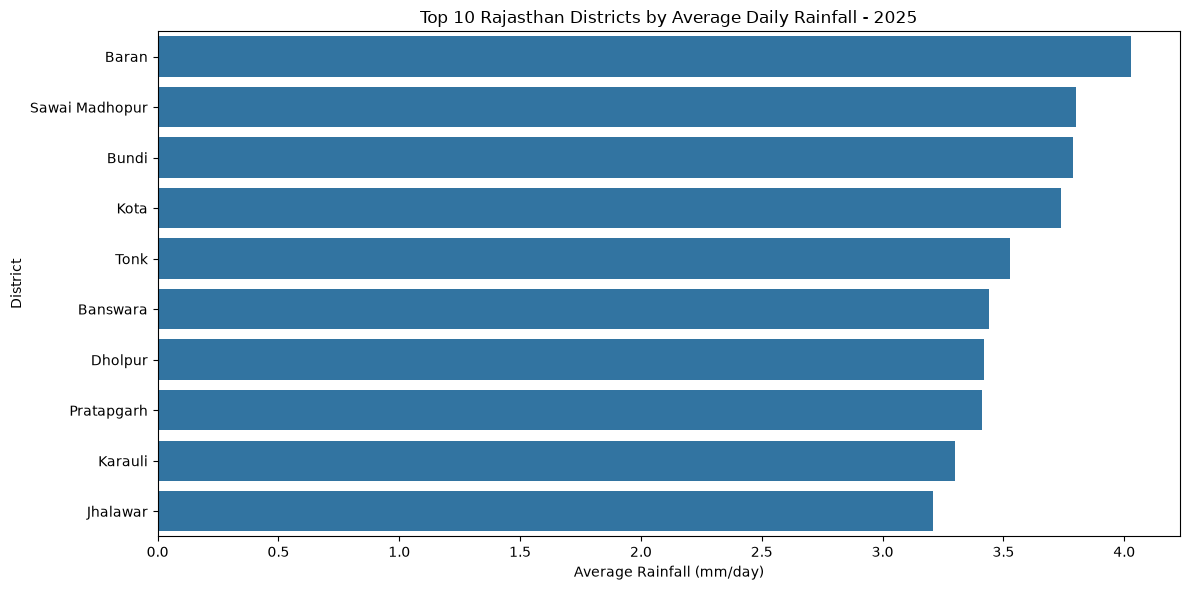

In [5]:
top_10_rainfall = district_rainfall.head(10)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_10_rainfall.values,
    y=top_10_rainfall.index
)

plt.title("Top 10 Rajasthan Districts by Average Daily Rainfall - 2025")
plt.xlabel("Average Rainfall (mm/day)")
plt.ylabel("District")
plt.tight_layout()
plt.show()

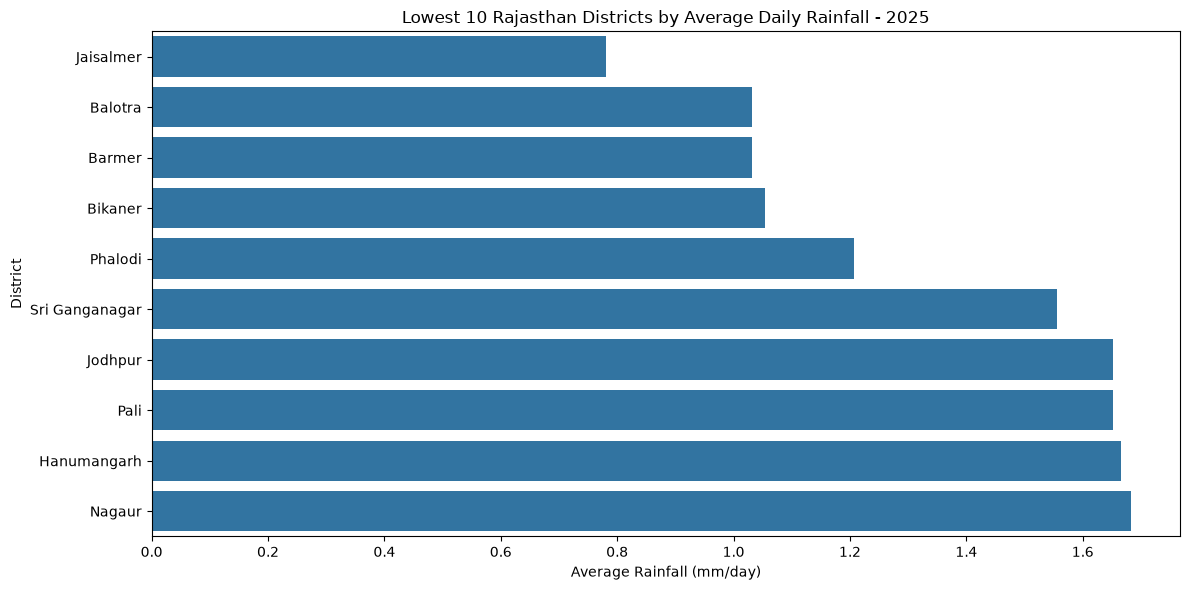

In [6]:
bottom_10_rainfall = district_rainfall.tail(10).sort_values()

plt.figure(figsize=(12, 6))

sns.barplot(
    x=bottom_10_rainfall.values,
    y=bottom_10_rainfall.index
)

plt.title("Lowest 10 Rajasthan Districts by Average Daily Rainfall - 2025")
plt.xlabel("Average Rainfall (mm/day)")
plt.ylabel("District")
plt.tight_layout()
plt.show()

In [8]:
df["date"] = pd.to_datetime(df["date"])

print(df["date"].dtype)

datetime64[us]


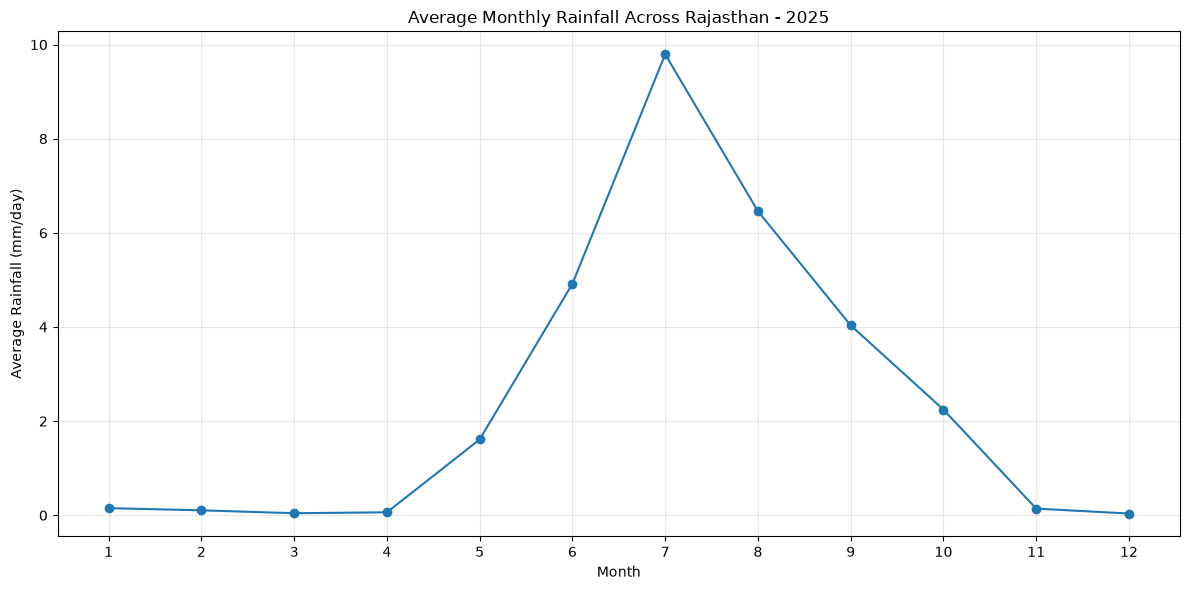

In [9]:
df["month"] = df["date"].dt.month

monthly_rainfall = (
    df.groupby("month")["rainfall_mm"]
    .mean()
)

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_rainfall.index,
    monthly_rainfall.values,
    marker="o"
)

plt.title("Average Monthly Rainfall Across Rajasthan - 2025")
plt.xlabel("Month")
plt.ylabel("Average Rainfall (mm/day)")
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
monthly_rainfall_table = (
    df.groupby("month")["rainfall_mm"]
    .mean()
    .round(2)
    .reset_index()
)

monthly_rainfall_table["month_name"] = pd.to_datetime(
    monthly_rainfall_table["month"],
    format="%m"
).dt.month_name()

monthly_rainfall_table[
    ["month", "month_name", "rainfall_mm"]
]

,month,month_name,rainfall_mm
0,1,January,0.15
1,2,February,0.11
2,3,March,0.04
3,4,April,0.06
4,5,May,1.61
5,6,June,4.92
6,7,July,9.79
7,8,August,6.46
8,9,September,4.03
9,10,October,2.24


In [11]:
district_monthly_rainfall = (
    df.groupby(["location", "month"])["rainfall_mm"]
    .mean()
    .reset_index()
)

district_monthly_rainfall.head(20)

,location,month,rainfall_mm
0,Ajmer,1,0.119032
1,Ajmer,2,0.085357
2,Ajmer,3,0.040645
3,Ajmer,4,0.061333
4,Ajmer,5,1.324839
5,Ajmer,6,3.984000
6,Ajmer,7,10.584194
7,Ajmer,8,6.119032
8,Ajmer,9,4.402667
9,Ajmer,10,1.700323


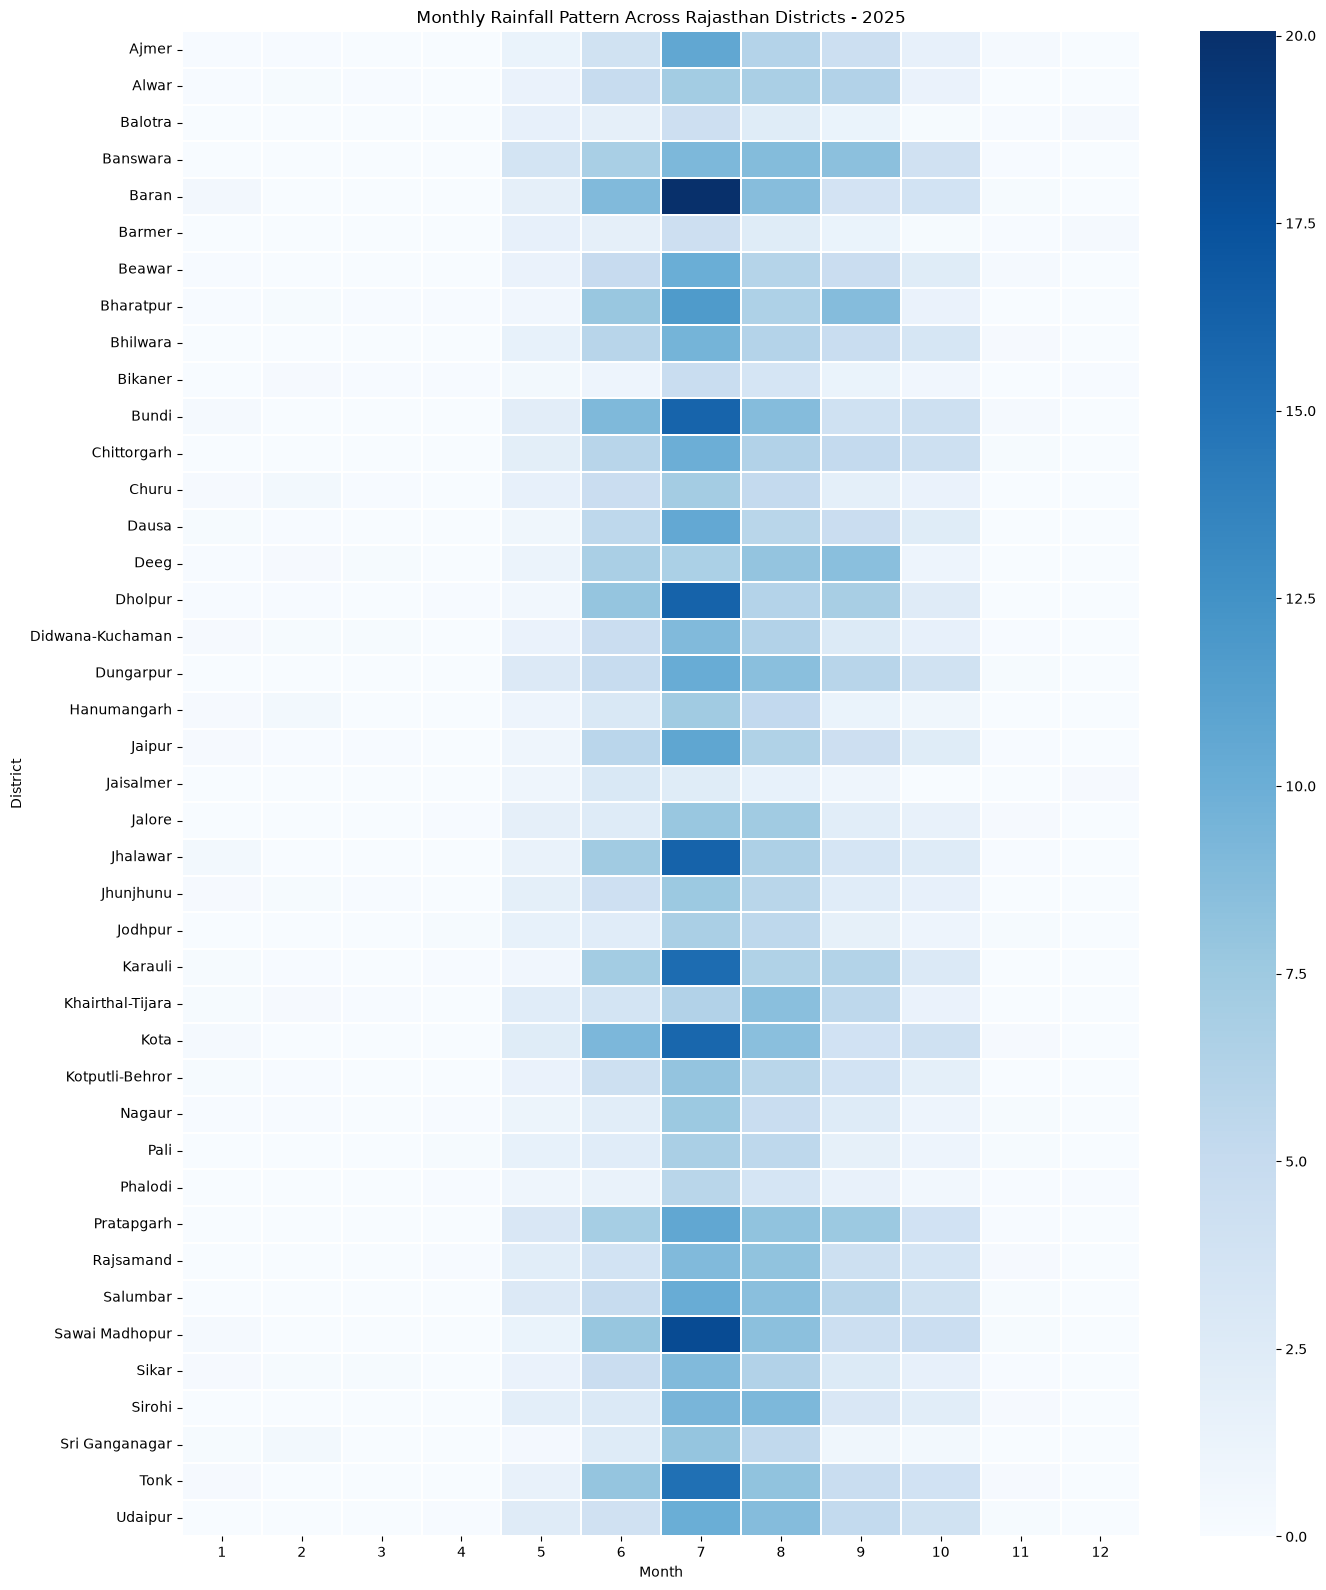

In [12]:
rainfall_heatmap = district_monthly_rainfall.pivot(
    index="location",
    columns="month",
    values="rainfall_mm"
)

plt.figure(figsize=(14, 16))

sns.heatmap(
    rainfall_heatmap,
    annot=False,
    cmap="Blues",
    linewidths=0.3
)

plt.title("Monthly Rainfall Pattern Across Rajasthan Districts - 2025")
plt.xlabel("Month")
plt.ylabel("District")
plt.tight_layout()
plt.show()

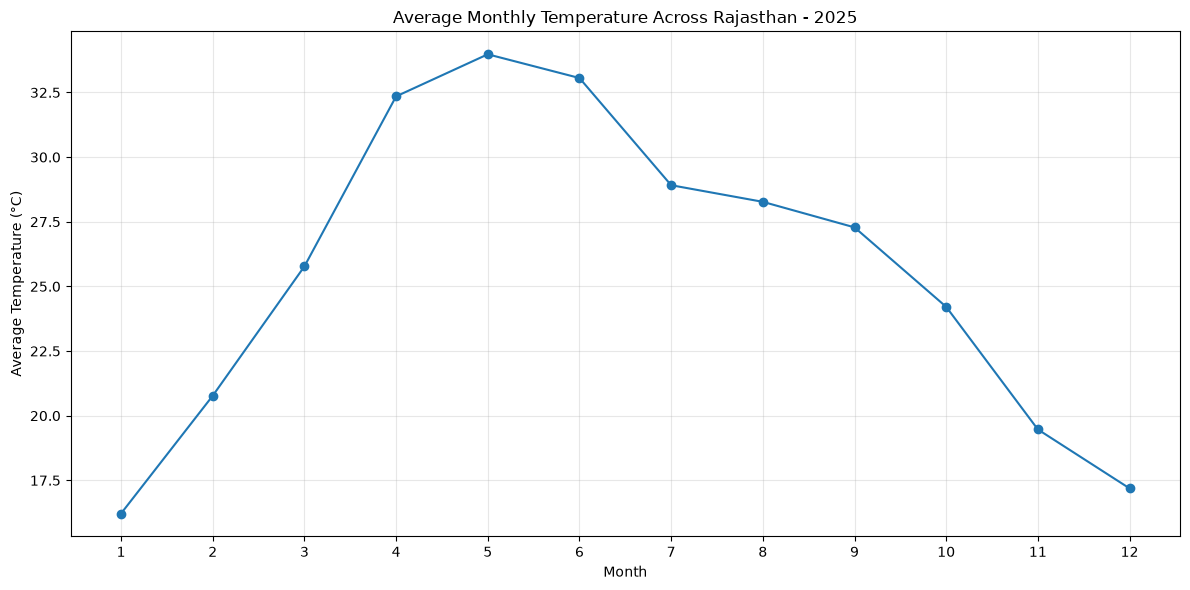

In [13]:
monthly_temperature = (
    df.groupby("month")["temperature_c"]
    .mean()
)

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_temperature.index,
    monthly_temperature.values,
    marker="o"
)

plt.title("Average Monthly Temperature Across Rajasthan - 2025")
plt.xlabel("Month")
plt.ylabel("Average Temperature (°C)")
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

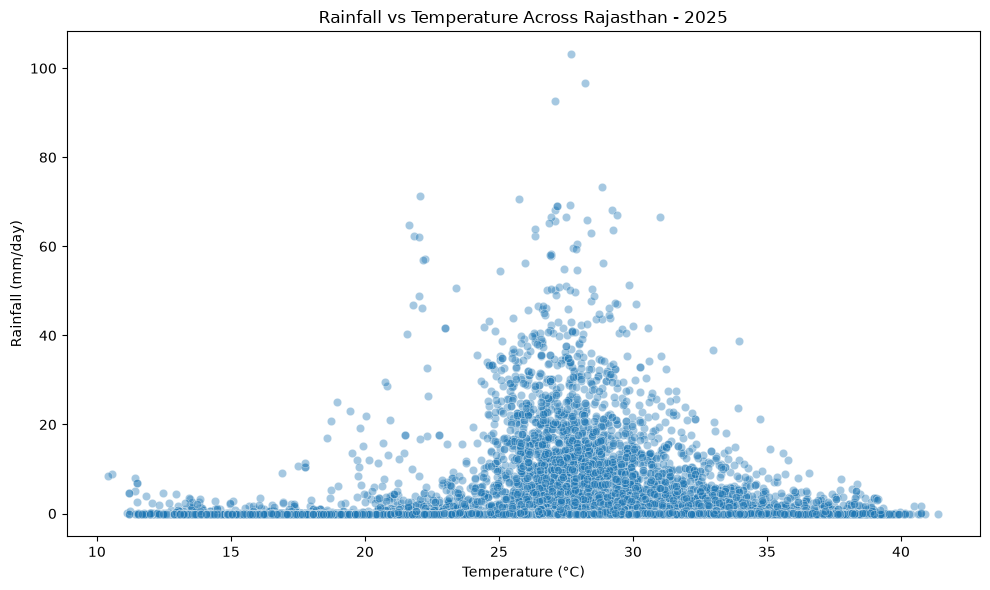

In [14]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="temperature_c",
    y="rainfall_mm",
    alpha=0.4
)

plt.title("Rainfall vs Temperature Across Rajasthan - 2025")
plt.xlabel("Temperature (°C)")
plt.ylabel("Rainfall (mm/day)")
plt.tight_layout()
plt.show()

In [15]:
correlation = df["rainfall_mm"].corr(df["temperature_c"])

print(f"Rainfall-Temperature Correlation: {correlation:.3f}")

Rainfall-Temperature Correlation: 0.119


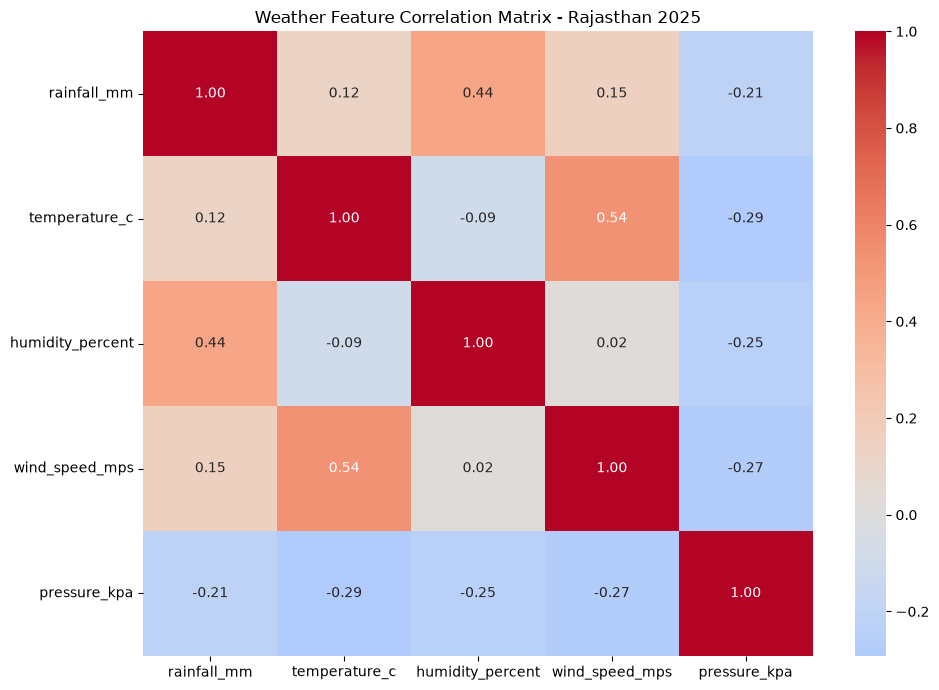

In [16]:
numeric_features = [
    "rainfall_mm",
    "temperature_c",
    "humidity_percent",
    "wind_speed_mps",
    "pressure_kpa"
]

correlation_matrix = df[numeric_features].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Weather Feature Correlation Matrix - Rajasthan 2025")
plt.tight_layout()
plt.show()

In [17]:
extreme_rainfall = df[df["rainfall_mm"] >= 50]

print("Extreme rainfall records:", len(extreme_rainfall))

print("\nDistrict-wise extreme rainfall events:")
print(
    extreme_rainfall["location"]
    .value_counts()
    .sort_values(ascending=False)
)

Extreme rainfall records: 47

District-wise extreme rainfall events:
location
Kota                6
Sawai Madhopur      6
Baran               5
Bundi               5
Bharatpur           3
Deeg                3
Dholpur             3
Tonk                3
Chittorgarh         2
Pratapgarh          2
Banswara            1
Bhilwara            1
Churu               1
Didwana-Kuchaman    1
Jaisalmer           1
Jhalawar            1
Jhunjhunu           1
Karauli             1
Sikar               1
Name: count, dtype: int64


In [18]:
max_rainfall_by_district = (
    df.groupby("location")["rainfall_mm"]
    .max()
    .sort_values(ascending=False)
)

max_rainfall_by_district.head(10)

location
Jhalawar            103.13
Baran                96.79
Bharatpur            92.54
Bundi                71.39
Kota                 70.70
Didwana-Kuchaman     69.03
Sikar                69.03
Dholpur              68.24
Sawai Madhopur       66.98
Jaisalmer            66.56
Name: rainfall_mm, dtype: float64

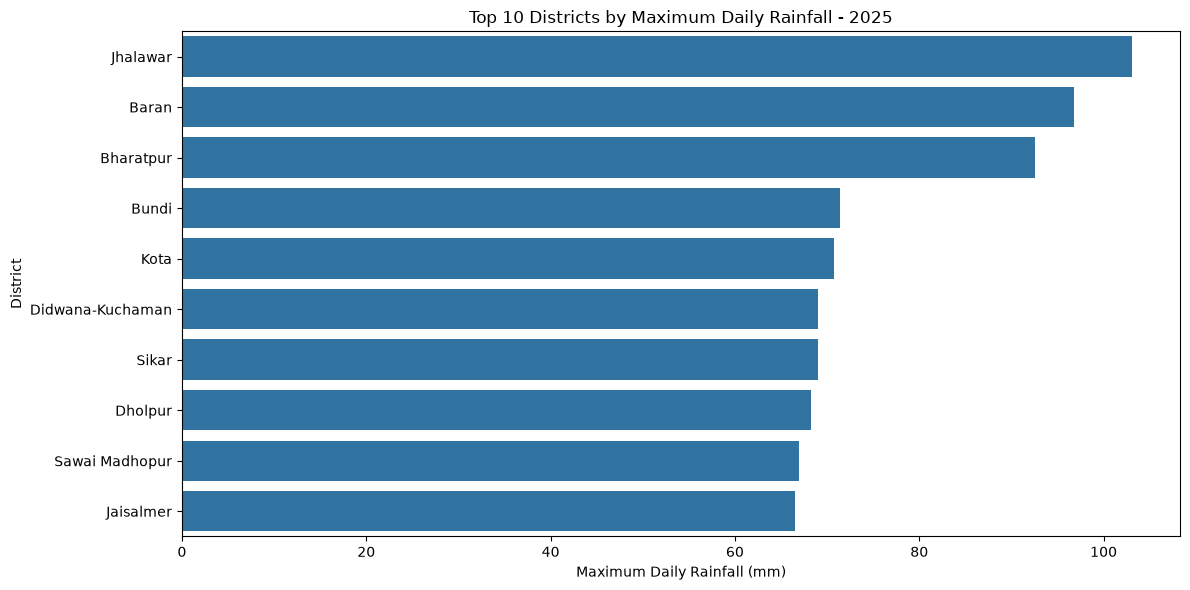

In [19]:
top_10_extreme = max_rainfall_by_district.head(10)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_10_extreme.values,
    y=top_10_extreme.index
)

plt.title("Top 10 Districts by Maximum Daily Rainfall - 2025")
plt.xlabel("Maximum Daily Rainfall (mm)")
plt.ylabel("District")
plt.tight_layout()
plt.show()

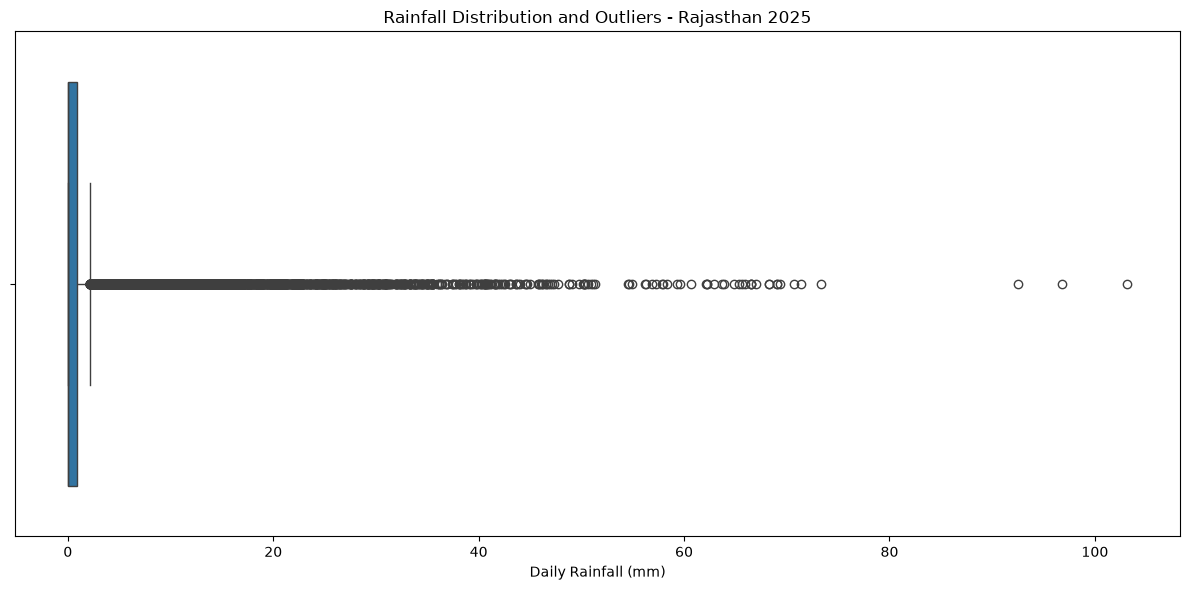

In [20]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    x=df["rainfall_mm"]
)

plt.title("Rainfall Distribution and Outliers - Rajasthan 2025")
plt.xlabel("Daily Rainfall (mm)")
plt.tight_layout()
plt.show()

In [21]:
df = df.sort_values(["location", "date"])

df["rainfall_1d"] = df["rainfall_mm"]

df.head()

,date,location,latitude,longitude,rainfall_mm,temperature_c,humidity_percent,wind_speed_mps,pressure_kpa,month,rainfall_1d
0,2025-01-01,Ajmer,26.4499,74.6399,0.0,14.73,50.11,1.37,97.36,1,0.0
1,2025-01-02,Ajmer,26.4499,74.6399,0.0,16.67,47.43,1.42,97.31,1,0.0
2,2025-01-03,Ajmer,26.4499,74.6399,0.0,18.04,44.12,1.78,97.23,1,0.0
3,2025-01-04,Ajmer,26.4499,74.6399,0.0,19.34,40.67,2.04,96.97,1,0.0
4,2025-01-05,Ajmer,26.4499,74.6399,0.0,18.04,46.23,1.76,96.93,1,0.0


In [22]:
df["rainfall_3d"] = (
    df.groupby("location")["rainfall_mm"]
    .rolling(window=3, min_periods=1)
    .sum()
    .reset_index(level=0, drop=True)
)

df[[
    "date",
    "location",
    "rainfall_mm",
    "rainfall_3d"
]].head(10)

,date,location,rainfall_mm,rainfall_3d
0,2025-01-01,Ajmer,0.0,0.0
1,2025-01-02,Ajmer,0.0,0.0
2,2025-01-03,Ajmer,0.0,0.0
3,2025-01-04,Ajmer,0.0,0.0
4,2025-01-05,Ajmer,0.0,0.0
5,2025-01-06,Ajmer,0.0,0.0
6,2025-01-07,Ajmer,0.0,0.0
7,2025-01-08,Ajmer,0.0,0.0
8,2025-01-09,Ajmer,0.0,0.0
9,2025-01-10,Ajmer,0.0,0.0


In [23]:
df["rainfall_7d"] = (
    df.groupby("location")["rainfall_mm"]
    .rolling(window=7, min_periods=1)
    .sum()
    .reset_index(level=0, drop=True)
)

df[[
    "date",
    "location",
    "rainfall_mm",
    "rainfall_3d",
    "rainfall_7d"
]].head(15)

,date,location,rainfall_mm,rainfall_3d,rainfall_7d
0,2025-01-01,Ajmer,0.00,0.00,0.00
1,2025-01-02,Ajmer,0.00,0.00,0.00
2,2025-01-03,Ajmer,0.00,0.00,0.00
3,2025-01-04,Ajmer,0.00,0.00,0.00
4,2025-01-05,Ajmer,0.00,0.00,0.00
5,2025-01-06,Ajmer,0.00,0.00,0.00
6,2025-01-07,Ajmer,0.00,0.00,0.00
7,2025-01-08,Ajmer,0.00,0.00,0.00
8,2025-01-09,Ajmer,0.00,0.00,0.00
9,2025-01-10,Ajmer,0.00,0.00,0.00


In [24]:
df["rainfall_change"] = (
    df.groupby("location")["rainfall_mm"]
    .diff()
    .fillna(0)
)

df[[
    "date",
    "location",
    "rainfall_mm",
    "rainfall_change"
]].head(10)

,date,location,rainfall_mm,rainfall_change
0,2025-01-01,Ajmer,0.0,0.0
1,2025-01-02,Ajmer,0.0,0.0
2,2025-01-03,Ajmer,0.0,0.0
3,2025-01-04,Ajmer,0.0,0.0
4,2025-01-05,Ajmer,0.0,0.0
5,2025-01-06,Ajmer,0.0,0.0
6,2025-01-07,Ajmer,0.0,0.0
7,2025-01-08,Ajmer,0.0,0.0
8,2025-01-09,Ajmer,0.0,0.0
9,2025-01-10,Ajmer,0.0,0.0


In [25]:
df["humidity_3d_avg"] = (
    df.groupby("location")["humidity_percent"]
    .rolling(window=3, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)

df[[
    "date",
    "location",
    "humidity_percent",
    "humidity_3d_avg"
]].head(10)

,date,location,humidity_percent,humidity_3d_avg
0,2025-01-01,Ajmer,50.11,50.110000
1,2025-01-02,Ajmer,47.43,48.770000
2,2025-01-03,Ajmer,44.12,47.220000
3,2025-01-04,Ajmer,40.67,44.073333
4,2025-01-05,Ajmer,46.23,43.673333
5,2025-01-06,Ajmer,46.25,44.383333
6,2025-01-07,Ajmer,42.11,44.863333
7,2025-01-08,Ajmer,29.02,39.126667
8,2025-01-09,Ajmer,35.92,35.683333
9,2025-01-10,Ajmer,44.35,36.430000


In [26]:
df["temperature_3d_avg"] = (
    df.groupby("location")["temperature_c"]
    .rolling(window=3, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)

df[[
    "date",
    "location",
    "temperature_c",
    "temperature_3d_avg"
]].head(10)

,date,location,temperature_c,temperature_3d_avg
0,2025-01-01,Ajmer,14.73,14.730000
1,2025-01-02,Ajmer,16.67,15.700000
2,2025-01-03,Ajmer,18.04,16.480000
3,2025-01-04,Ajmer,19.34,18.016667
4,2025-01-05,Ajmer,18.04,18.473333
5,2025-01-06,Ajmer,14.02,17.133333
6,2025-01-07,Ajmer,12.11,14.723333
7,2025-01-08,Ajmer,15.04,13.723333
8,2025-01-09,Ajmer,15.57,14.240000
9,2025-01-10,Ajmer,15.58,15.396667


In [27]:
df["wind_speed_3d_avg"] = (
    df.groupby("location")["wind_speed_mps"]
    .rolling(window=3, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)

df[[
    "date",
    "location",
    "wind_speed_mps",
    "wind_speed_3d_avg"
]].head(10)

,date,location,wind_speed_mps,wind_speed_3d_avg
0,2025-01-01,Ajmer,1.37,1.370000
1,2025-01-02,Ajmer,1.42,1.395000
2,2025-01-03,Ajmer,1.78,1.523333
3,2025-01-04,Ajmer,2.04,1.746667
4,2025-01-05,Ajmer,1.76,1.860000
5,2025-01-06,Ajmer,2.32,2.040000
6,2025-01-07,Ajmer,1.80,1.960000
7,2025-01-08,Ajmer,1.22,1.780000
8,2025-01-09,Ajmer,2.17,1.730000
9,2025-01-10,Ajmer,3.44,2.276667


In [28]:
df["pressure_3d_avg"] = (
    df.groupby("location")["pressure_kpa"]
    .rolling(window=3, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)

df[[
    "date",
    "location",
    "pressure_kpa",
    "pressure_3d_avg"
]].head(10)

,date,location,pressure_kpa,pressure_3d_avg
0,2025-01-01,Ajmer,97.36,97.360000
1,2025-01-02,Ajmer,97.31,97.335000
2,2025-01-03,Ajmer,97.23,97.300000
3,2025-01-04,Ajmer,96.97,97.170000
4,2025-01-05,Ajmer,96.93,97.043333
5,2025-01-06,Ajmer,97.22,97.040000
6,2025-01-07,Ajmer,97.40,97.183333
7,2025-01-08,Ajmer,97.21,97.276667
8,2025-01-09,Ajmer,97.20,97.270000
9,2025-01-10,Ajmer,97.22,97.210000


In [29]:
df["month"] = df["date"].dt.month

df["is_monsoon"] = df["month"].isin([6, 7, 8, 9]).astype(int)

df[[
    "date",
    "location",
    "month",
    "is_monsoon"
]].head(10)

,date,location,month,is_monsoon
0,2025-01-01,Ajmer,1,0
1,2025-01-02,Ajmer,1,0
2,2025-01-03,Ajmer,1,0
3,2025-01-04,Ajmer,1,0
4,2025-01-05,Ajmer,1,0
5,2025-01-06,Ajmer,1,0
6,2025-01-07,Ajmer,1,0
7,2025-01-08,Ajmer,1,0
8,2025-01-09,Ajmer,1,0
9,2025-01-10,Ajmer,1,0


In [30]:
feature_columns = [
    "rainfall_mm",
    "rainfall_1d",
    "rainfall_3d",
    "rainfall_7d",
    "rainfall_change",
    "temperature_c",
    "temperature_3d_avg",
    "humidity_percent",
    "humidity_3d_avg",
    "wind_speed_mps",
    "wind_speed_3d_avg",
    "pressure_kpa",
    "pressure_3d_avg",
    "month",
    "is_monsoon"
]

df[feature_columns].info()

<class 'pandas.DataFrame'>
Index: 14965 entries, 0 to 14964
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   rainfall_mm         14965 non-null  float64
 1   rainfall_1d         14965 non-null  float64
 2   rainfall_3d         14965 non-null  float64
 3   rainfall_7d         14965 non-null  float64
 4   rainfall_change     14965 non-null  float64
 5   temperature_c       14965 non-null  float64
 6   temperature_3d_avg  14965 non-null  float64
 7   humidity_percent    14965 non-null  float64
 8   humidity_3d_avg     14965 non-null  float64
 9   wind_speed_mps      14965 non-null  float64
 10  wind_speed_3d_avg   14965 non-null  float64
 11  pressure_kpa        14965 non-null  float64
 12  pressure_3d_avg     14965 non-null  float64
 13  month               14965 non-null  int32  
 14  is_monsoon          14965 non-null  int64  
dtypes: float64(13), int32(1), int64(1)
memory usage: 1.8 MB


In [31]:
print("Total rows:", len(df))
print("Total features:", len(feature_columns))

print("\nFeature columns:")
for feature in feature_columns:
    print("-", feature)

Total rows: 14965
Total features: 15

Feature columns:
- rainfall_mm
- rainfall_1d
- rainfall_3d
- rainfall_7d
- rainfall_change
- temperature_c
- temperature_3d_avg
- humidity_percent
- humidity_3d_avg
- wind_speed_mps
- wind_speed_3d_avg
- pressure_kpa
- pressure_3d_avg
- month
- is_monsoon
